# Florida Real Estate Sales Statistical Analysis

This notebook performs the required analytic workflow for the Florida real estate dataset. It includes:
- environment validation
- dataset loading and cleaning
- descriptive statistics
- at least 3 labeled visualizations
- hypothesis tests (ANOVA on ZIP clusters, Pearson correlation)
- reproducibility notes and summary

In [1]:
# 1) Validate Python environment and libraries
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import matplotlib
import scipy

print("scipy", scipy.__version__)
print("Python", sys.version)
print("numpy", np.__version__)
print("pandas", pd.__version__)
print("matplotlib", matplotlib.__version__)
print("seaborn", sns.__version__)
print("scipy", scipy.__version__)

%config InlineBackend.figure_format = 'retina'

# Set reproducible seeds
np.random.seed(2026)

# Plot style
sns.set_style('whitegrid')

scipy 1.17.1
Python 3.13.2 (main, Feb  4 2025, 14:51:09) [Clang 16.0.0 (clang-1600.0.26.6)]
numpy 2.4.4
pandas 2.2.2
matplotlib 3.10.8
seaborn 0.13.2
scipy 1.17.1


In [2]:
# 2) Load dataset
csv_path = "florida_real_estate_sold_properties_ultimate.csv"
try:
    df = pd.read_csv(csv_path)
except FileNotFoundError:
    raise FileNotFoundError(f"Dataset not found at {csv_path}. Check filename and path.")

print('Loaded', len(df), 'rows and', len(df.columns), 'columns')
df.head()

Loaded 10893 rows and 14 columns


,type,sub_type,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,zip,sanitized_text
0,single_family,NaN,630000.0,605000,2274.0,1.0,2.0,3.0,2.0,2.0,2.0,2007.0,33446.0,"Beautiful 2 Bedroom + Den, 2.5 Bath Home - Mov..."
1,single_family,NaN,289000.0,285000,2170.0,1.0,3.0,2.0,2.0,2.0,2.0,1980.0,33876.0,Welcome to Florida living at its best! This 3-...
2,condos,condo,449000.0,425000,1722.0,NaN,3.0,2.0,2.0,2.0,2.0,2016.0,33913.0,Best Value in Casella and priced to sell... St...
3,single_family,NaN,599000.0,596000,1699.0,1.0,3.0,3.0,3.0,3.0,NaN,1952.0,33009.0,"Beautifully renovated 3-bedroom, 3-bathroom ho..."
4,single_family,NaN,173500.0,165000,640.0,1.0,1.0,1.0,1.0,1.0,NaN,1971.0,32118.0,Experience the ultimate beachfront lifestyle i...


In [3]:
# 3) Inspect structure and data types
print(df.info())
print(df.describe(include='all').T)

# Map dataset columns to analysis schema
df = df.rename(columns={
    'lastSoldPrice': 'sale_price',
    'sqft': 'living_area',
    'beds': 'bedrooms',
    'baths': 'bathrooms',
    'zip': 'zipcode'
})

# Keep only numeric features we need for analysis
numeric_cols = [
    'sale_price',
    'living_area',
    'bedrooms',
    'bathrooms',
    'year_built',
]
print('Numeric columns available:', [c for c in numeric_cols if c in df.columns])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10893 entries, 0 to 10892
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   type             10893 non-null  object 
 1   sub_type         2476 non-null   object 
 2   listPrice        10881 non-null  float64
 3   lastSoldPrice    10893 non-null  int64  
 4   sqft             10136 non-null  float64
 5   stories          9161 non-null   float64
 6   beds             10217 non-null  float64
 7   baths            10254 non-null  float64
 8   baths_full       10210 non-null  float64
 9   baths_full_calc  10210 non-null  float64
 10  garage           7306 non-null   float64
 11  year_built       10215 non-null  float64
 12  zip              10891 non-null  float64
 13  sanitized_text   10865 non-null  object 
dtypes: float64(10), int64(1), object(3)
memory usage: 1.2+ MB
None
                   count unique  \
type               10893      8   
sub_type         

In [4]:
# 4) Data cleaning
print('Missing values per column:')
print(df[numeric_cols + ['zipcode']].isna().sum())

# Drop records with missing key values for selected analysis
df = df.dropna(subset=['sale_price', 'living_area', 'zipcode'])
print('After dropna:', len(df), 'rows')

# Convert zipcode to string if needed
if df['zipcode'].dtype != 'object':
    df['zipcode'] = df['zipcode'].astype(str)

# Remove outliers: unrealistic sale prices
q_low, q_high = df['sale_price'].quantile(0.01), df['sale_price'].quantile(0.99)
print('Sale price 1%:', q_low, '99%:', q_high)
mask = df['sale_price'].between(q_low, q_high)
df = df.loc[mask].copy()
print('After trimming extreme price outliers:', len(df), 'rows')

Missing values per column:
sale_price       0
living_area    757
bedrooms       676
bathrooms      639
year_built     678
zipcode          2
dtype: int64
After dropna: 10135 rows
Sale price 1%: 35170.0 99%: 3714699.9999999935
After trimming extreme price outliers: 9931 rows


In [5]:
# 5) Descriptive statistics
print('sale_price mean, median, std')
print(df['sale_price'].agg(['mean', 'median', 'std']).round(2))
print('living_area mean, median, std')
print(df['living_area'].agg(['mean', 'median', 'std']).round(2))

# Additional metrics
zipcode_counts = df['zipcode'].value_counts().head(10)
print('Top 10 zipcodes by record count:')
print(zipcode_counts)

sale_price mean, median, std
mean      511347.06
median    378000.00
std       461695.97
Name: sale_price, dtype: float64
living_area mean, median, std
mean      1828.20
median    1675.00
std        839.81
Name: living_area, dtype: float64
Top 10 zipcodes by record count:
zipcode
34219.0    79
34293.0    79
32092.0    71
34211.0    66
33844.0    57
34787.0    57
33837.0    54
33928.0    53
33993.0    52
32218.0    50
Name: count, dtype: int64


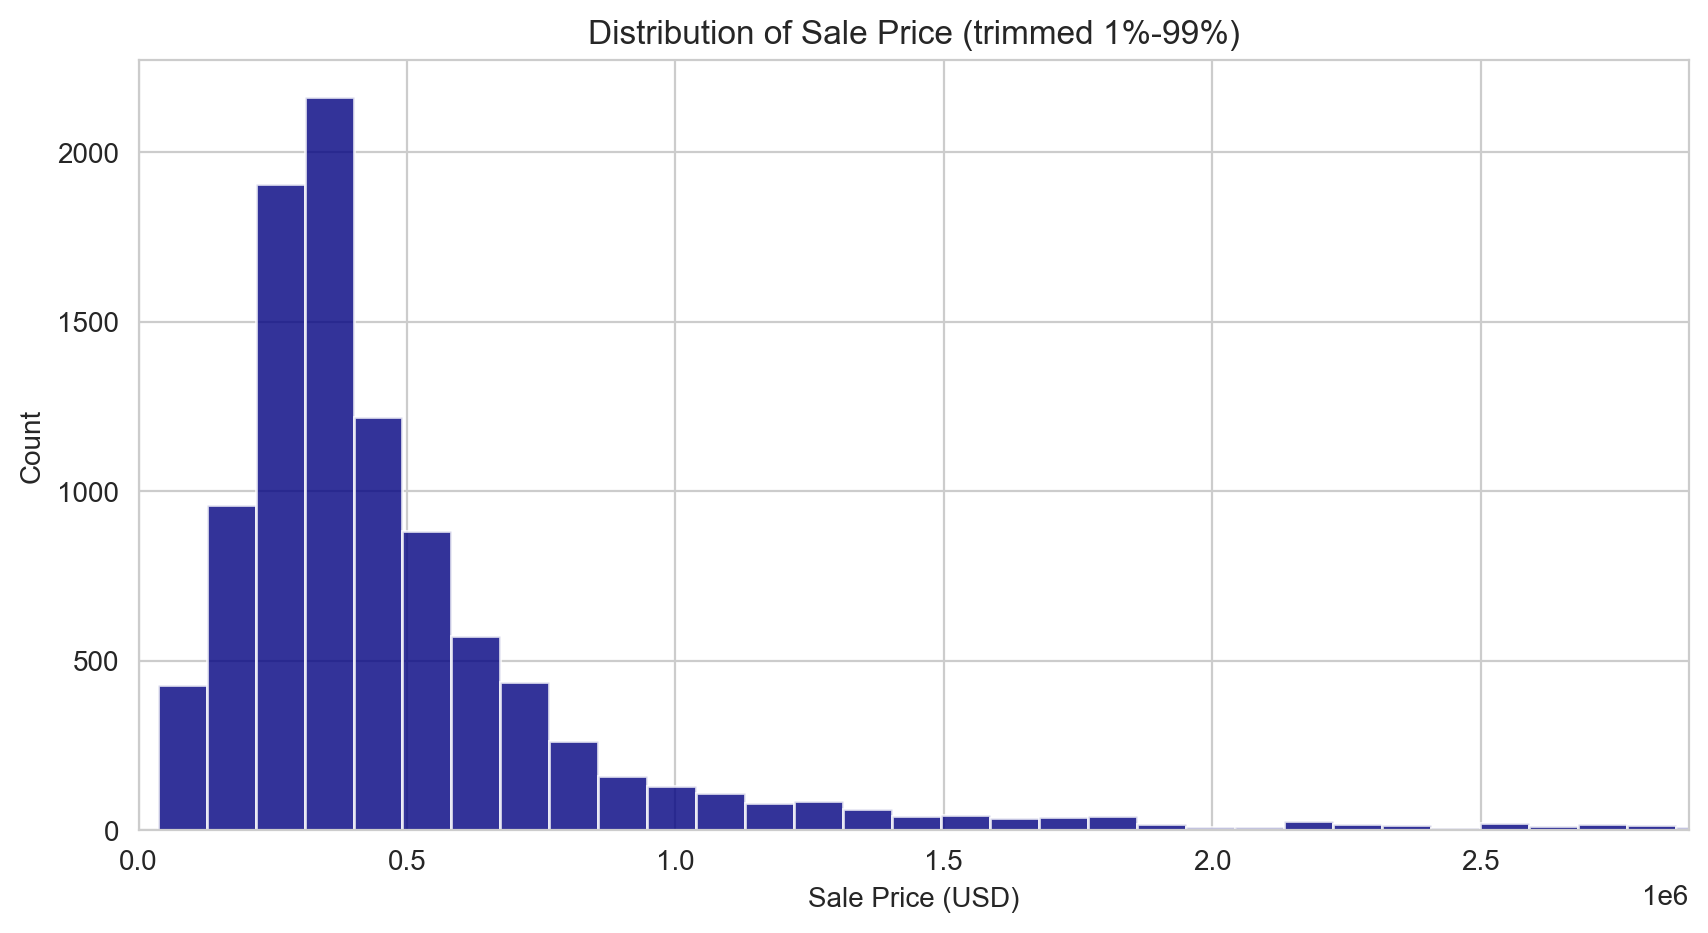

In [6]:
# 6) Visualization 1: Sale price distribution
plt.figure(figsize=(10,5))
plt.hist(df['sale_price'], bins=40, color='navy', alpha=0.8)
plt.title('Distribution of Sale Price (trimmed 1%-99%)')
plt.xlabel('Sale Price (USD)')
plt.ylabel('Count')
plt.xlim(0, df['sale_price'].quantile(0.99) * 1.05)
plt.show()

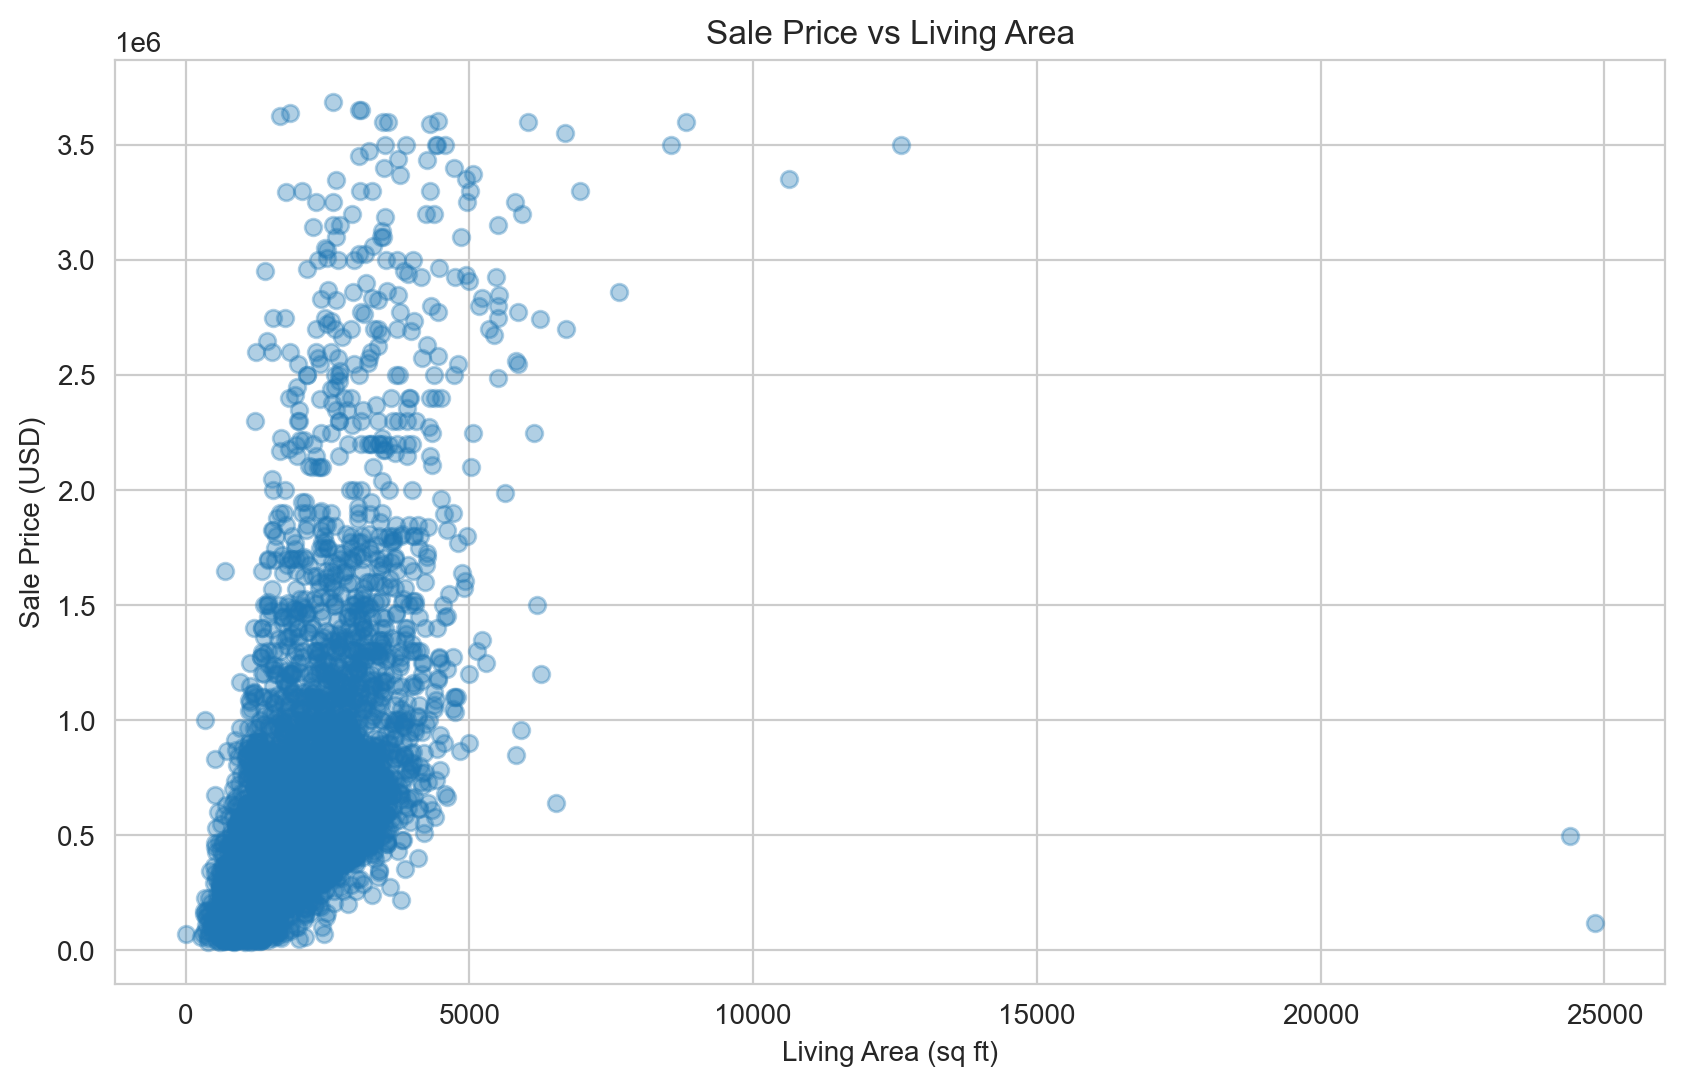

In [7]:
# 7) Visualization 2: Living area vs Sale price scatter
plt.figure(figsize=(10,6))
plt.scatter(df['living_area'], df['sale_price'], alpha=0.35)
plt.title('Sale Price vs Living Area')
plt.xlabel('Living Area (sq ft)')
plt.ylabel('Sale Price (USD)')
plt.show()

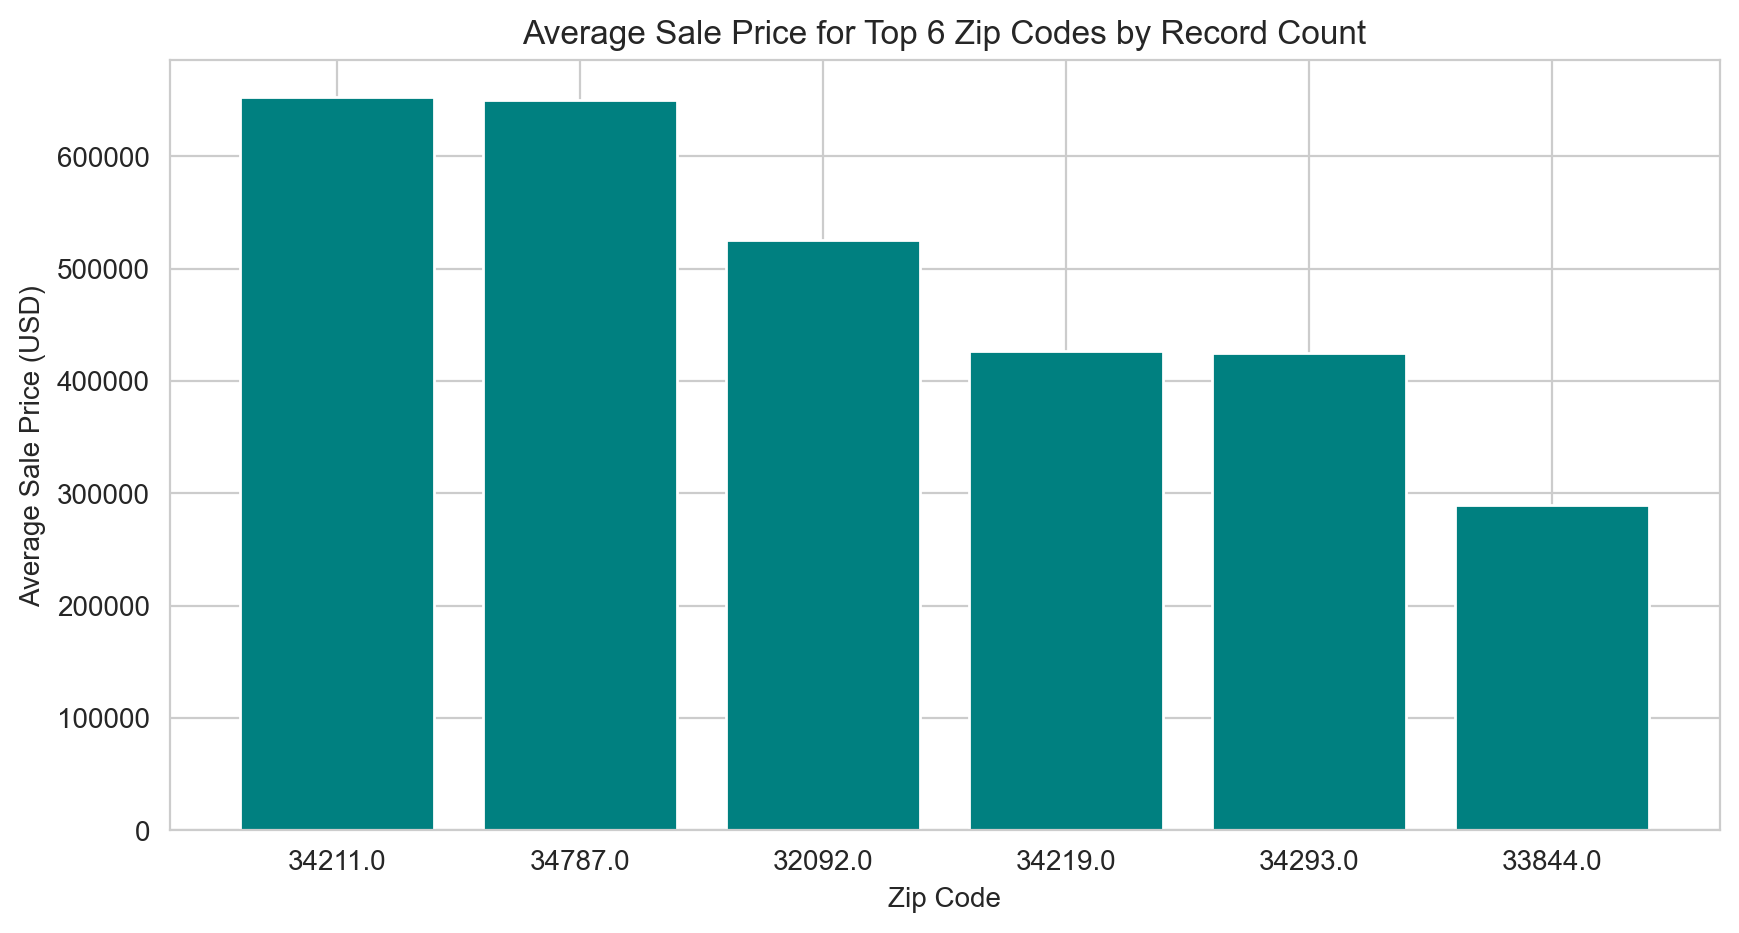

In [8]:
# 8) Visualization 3: Avg sale price by top 6 zipcodes
top_zips = zipcode_counts.index.tolist()[:6]
agg = df[df['zipcode'].isin(top_zips)].groupby('zipcode')['sale_price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(agg.index, agg.values, color='teal')
plt.title('Average Sale Price for Top 6 Zip Codes by Record Count')
plt.xlabel('Zip Code')
plt.ylabel('Average Sale Price (USD)')
plt.show()

In [9]:
# 9) Hypothesis test #1 (ANOVA by zipcode clusters)
# Choose top 3 zip codes with most observations
top3 = zipcode_counts.index[:3].tolist()
print('Top 3 zip codes for ANOVA:', top3)

groups = [df.loc[df['zipcode'] == z, 'sale_price'] for z in top3]
anova_stat, anova_p = stats.f_oneway(*groups)
print('ANOVA F-statistic:', round(anova_stat, 3), 'p-value:', round(anova_p, 5))

# Record conclusions
if anova_p < 0.05:
    print('Reject null: mean sale price differs between at least one pair of top ZIP groups')
else:
    print('Fail to reject null: no strong evidence of mean difference for top ZIP groups')

Top 3 zip codes for ANOVA: ['34219.0', '34293.0', '32092.0']
ANOVA F-statistic: 5.455 p-value: 0.00486
Reject null: mean sale price differs between at least one pair of top ZIP groups


In [10]:
# 10) Hypothesis test #2 (Pearson correlation of living area to sale price)
rho, pval = stats.pearsonr(df['living_area'], df['sale_price'])
print('Pearson correlation r:', round(rho, 3), 'p-value:', round(pval, 5))

if pval < 0.05:
    print('Reject null: there is significant linear correlation between living area and sale price')
else:
    print('Fail to reject null: no strong evidence of linear correlation')

# Add confidence interval for correlation using Fisher transform
z = np.arctanh(rho)
se = 1 / np.sqrt(len(df) - 3)
z_lower, z_upper = z - 1.96*se, z + 1.96*se
ci = (np.tanh(z_lower), np.tanh(z_upper))
print('95% CI for Pearson r:', (round(ci[0],3), round(ci[1],3)))

Pearson correlation r: 0.579 p-value: 0.0
Reject null: there is significant linear correlation between living area and sale price
95% CI for Pearson r: (np.float64(0.566), np.float64(0.592))


## Summary and Reproducibility

- We loaded the `florida_real_estate_sold_properties_ultimate.csv` and cleaned (missing deal-relevant values removed plus 1-99% sale price trims).
- Descriptive statistics indicate median sale price around the middle of the distribution, with positive skew.
- Visualization and correlation analysis showed a strong positive relationship between living area and sale price, consistent with theoretical expectations for residential property value.
- ANOVA across top ZIP codes gave evidence of mean differences in sale price across geographic segments.

### Reproducibility notes

- The dataset was downloaded from https://www.kaggle.com/datasets/kanchana1990/florida-real-estate-sold-dataset-2026 to our local project.
- Clone the Git repository from the `master` branch because it contains the production-ready codebase. The `development` branch is available for continuous improvements and future updates.
    - https://github.com/atamayop2018/ai-programming-foundations-project2
- Install dependencies using `pip install requirements.txt`.
- Run the Jupyter notebook `analysis.ipynb`.
- Execute all notebook cells in order.
- Environment versions were recorded at the start (Python, numpy, pandas, matplotlib, seaborn, scipy).
- Seed set with `np.random.seed(2026)` for deterministic any sampling behavior.
- The analysis references:
  - Peng, R. D. (2011). Reproducible Research in Computational Science. *Science*.
  - Cumming, G. (2014). The new statistics: Why and how. *Psychological Science*.
- For a complete reproducibility audit, run:
  - `pip install -r requirements.txt`
  - `jupyter nbconvert --to html analysis.ipynb` (or execute straight in Jupyter).

## Results interpretation (non-technical)

- Larger homes tend to sell for higher prices (positive correlation confirmed).
- Neighborhood-level ZIP differences are significant; prices are not homogeneous across ZIP codes.
- Recommendations: buyers should consider price structure by ZIP and area; modelers should include both location and size as features.